# Librerias

**Si se requiere descargar alguna libreria para ejecutar en el entorno, agregarlas debajo**

In [566]:
import requests

In [567]:
import pandas as pd

In [568]:
import ast

In [569]:
import unicodedata

In [570]:
import re

In [571]:
from sklearn.ensemble import RandomForestClassifier

In [572]:
from sklearn.preprocessing import LabelEncoder

In [573]:
from sklearn.metrics import confusion_matrix, classification_report

In [574]:
import seaborn as sns

In [575]:
import matplotlib.pyplot as plt

In [576]:
from sklearn.model_selection import train_test_split

In [577]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [578]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [579]:
from sklearn.cluster import KMeans

In [580]:
from sklearn.decomposition import PCA

# Funciones

**Funcion para descargar los datos desde la API oficial de BANAVIM:** [API BANAVIM ABIERTO](https://banavimabierto.mx/api.php)

In [581]:
def DescargarDatasettAPI(url):
  params = {
      "entidad": "Veracruz Ignacio de la Llave",
      "desde": "2018-01-01",
      "hasta": "2023-12-31",
      "limiteInicio": 0,
      "cantidad": 50000
  }

  response = requests.get(url, params=params)

  if response.status_code == 200:
      data = response.json()

      registros = data.get('data', [])

      parsed_data = []
      for r in registros:
          clean_dict = {k: v for k, v in r.items() if not isinstance(k, str) or not k.isdigit()}
          parsed_data.append(clean_dict)

      return pd.DataFrame(parsed_data)

**Funcion para quitar acentos de los registros de una columna**

In [582]:
def QuitarAcentos(texto):
    return ''.join(
        c for c in unicodedata.normalize('NFKD', texto)
        if not unicodedata.combining(c)
    )

**Funciones de limpieza**

In [583]:
def TipoViolencia(row):
    for col in violencia_cols:
        if row[col] == 1:
            return col.split('_', 1)[1].capitalize()
    return 'Desconocido'

In [584]:
def LimpiarConoce(valor):
    valor = str(valor).strip().upper()
    if valor in ['SI', 'SE']:
        return 'Si'
    elif valor == 'NO':
        return 'No'
    else:
        return 'Desconocido'

In [585]:
def LimpiarDelincuencia(valor):
    valor = str(valor).strip().capitalize()
    if valor == 'Si':
        return 'Si'
    elif valor == 'No':
        return 'No'
    else:
        return 'Desconocido'

In [586]:
def LimpiarVictimaTrata(valor):
    valor = str(valor).strip().capitalize()
    if valor == 'Si':
        return 'Si'
    elif valor == 'No':
        return 'No'
    else:
        return 'Desconocido'

In [587]:
def LimpiarDroga(valor):
    valor = str(valor).strip().upper()
    if valor == 'SI':
        return 'Si'
    elif valor == 'NO':
        return 'No'
    else:
        return 'Desconocido'

In [588]:
def TipoDroga(row):
    for col in droga_cols:
        if row[col] == 1:
            return col.replace('droga_', '').capitalize()
    return 'Desconocido'

In [589]:
def LimpiarDrogaConsumo(valor):
    valor = str(valor).strip().upper()
    if valor == 'SI':
        return 'Si'
    elif valor == 'NO':
        return 'No'
    else:
        return 'Desconocido'

In [590]:
def LimpiarArma(valor):
    valor = str(valor).strip().upper()
    if valor == 'SI':
        return 'Si'
    elif valor == 'NO':
        return 'No'
    else:
        return 'Desconocido'

In [591]:
def LimpiarArmaPortaba(valor):
    valor = str(valor).strip().upper()
    if valor == 'SI':
        return 'Si'
    elif valor == 'NO':
        return 'No'
    else:
        return 'Desconocido'

In [592]:
def TipoArma(row):
    for col in arma_cols:
        if row[col] == 1:
            return col.replace('arma_', '').replace('_', ' ').capitalize()
    return 'Desconocido'

In [593]:
def QuitarAcentos(text):
    text = str(text)
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

In [594]:
def LimpiarMunicipio(text):
    text = QuitarAcentos(text)
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    text = text.title()
    return text

In [595]:
def Normalizar(text):
    text = str(text).strip()
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

In [596]:
def Limpiar(text):
    text = str(text).strip().title()
    return ''.join(
        c for c in unicodedata.normalize('NFD', text)
        if unicodedata.category(c) != 'Mn'
    )

# Casos

In [786]:
url = "https://cobasys.app/backend/api/casos"

casos = DescargarDatasettAPI(url)

In [787]:
casos.shape

(11697, 32)

In [788]:
casos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11697 entries, 0 to 11696
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   idcaso                   11697 non-null  int64 
 1   fecharecepcion           11697 non-null  object
 2   estado                   11697 non-null  object
 3   municipio                11697 non-null  object
 4   fechahechos              11697 non-null  object
 5   lugarhechos              11697 non-null  object
 6   conoce_agresor           11697 non-null  object
 7   modalidad_violencia      11697 non-null  object
 8   violencia_fisica         11697 non-null  int64 
 9   violencia_psicologica    11697 non-null  int64 
 10  violencia_sexual         11697 non-null  int64 
 11  violencia_economica      11697 non-null  int64 
 12  violencia_patrimonial    11697 non-null  int64 
 13  violencia_otra           11697 non-null  int64 
 14  delincuencia_organizada  11697 non-nul

In [789]:
casos['fecharecepcion'] = pd.to_datetime(casos['fecharecepcion'], errors='coerce')

In [790]:
casos[casos['fecharecepcion'].isna()]

,idcaso,fecharecepcion,estado,municipio,fechahechos,lugarhechos,conoce_agresor,modalidad_violencia,violencia_fisica,violencia_psicologica,...,arma_portaba,arma_chacos,arma_macana,arma_blanca,arma_punzocortante,arma_machete,arma_proyectil,arma_fuego_corta,arma_fuego_larga,arma_fuego_larga_otra


In [791]:
casos['estado'].unique()

array(['Veracruz Ignacio de la Llave'], dtype=object)

In [792]:
casos['municipio'].unique()

array(['Zozocolco de Hidalgo', 'San Andrés Tuxtla', 'Tihuatlán',
       'La Perla', 'Ayahualulco', 'Chihuahua', 'Pánuco', 'Torreón',
       'Tequila', 'Nogales', 'Tlapacoyan', 'Veracruz', 'Boca del Río',
       'Uxpanapa', 'Tuxpan', 'Orizaba', 'Angel R. Cabada',
       'Poza Rica de Hidalgo', 'Córdoba', 'Coatepec',
       'Nuevo Casas Grandes', 'Papantla', 'Alvarado', 'Río Blanco',
       'Fortín', 'Huatusco', 'Mariano Escobedo', 'Cerro Azul',
       'Coscomatepec', 'Misantla', 'Ixtaczoquitlán', 'Acayucan', 'Perote',
       'Atzacan', 'Catemaco', 'Cosamaloapan de Carpio', 'Minatitlán',
       'Othón P. Blanco', 'Coatzacoalcos', 'Las Choapas',
       'Tuxtla Gutiérrez', 'Tlaxcala', 'Cotaxtla', 'Álamo Temapache',
       'Zongolica', 'Tantoyuca', 'Xalapa', 'Texistepec', 'Chilón',
       'Martínez de la Torre', 'Tempoal', 'Tierra Blanca',
       'Ixhuatlán de Madero', 'Agua Dulce', 'Paso del Macho', 'Chalma',
       'Yanga', 'Coatzintla', 'Tezonapa', 'San Juan Evangelista',
       'Santiag

In [793]:
casos['municipio'] = casos['municipio'].str.replace('\xad', '', regex=True)

In [794]:
casos['municipio'].unique()

array(['Zozocolco de Hidalgo', 'San Andrés Tuxtla', 'Tihuatlán',
       'La Perla', 'Ayahualulco', 'Chihuahua', 'Pánuco', 'Torreón',
       'Tequila', 'Nogales', 'Tlapacoyan', 'Veracruz', 'Boca del Río',
       'Uxpanapa', 'Tuxpan', 'Orizaba', 'Angel R. Cabada',
       'Poza Rica de Hidalgo', 'Córdoba', 'Coatepec',
       'Nuevo Casas Grandes', 'Papantla', 'Alvarado', 'Río Blanco',
       'Fortín', 'Huatusco', 'Mariano Escobedo', 'Cerro Azul',
       'Coscomatepec', 'Misantla', 'Ixtaczoquitlán', 'Acayucan', 'Perote',
       'Atzacan', 'Catemaco', 'Cosamaloapan de Carpio', 'Minatitlán',
       'Othón P. Blanco', 'Coatzacoalcos', 'Las Choapas',
       'Tuxtla Gutiérrez', 'Tlaxcala', 'Cotaxtla', 'Álamo Temapache',
       'Zongolica', 'Tantoyuca', 'Xalapa', 'Texistepec', 'Chilón',
       'Martínez de la Torre', 'Tempoal', 'Tierra Blanca',
       'Ixhuatlán de Madero', 'Agua Dulce', 'Paso del Macho', 'Chalma',
       'Yanga', 'Coatzintla', 'Tezonapa', 'San Juan Evangelista',
       'Santiag

In [795]:
reemplazo = {
    'í\x81lamo Temapache': 'Álamo Temapache'
}

casos['municipio'] = casos['municipio'].replace(reemplazo)

casos['municipio'].unique()

array(['Zozocolco de Hidalgo', 'San Andrés Tuxtla', 'Tihuatlán',
       'La Perla', 'Ayahualulco', 'Chihuahua', 'Pánuco', 'Torreón',
       'Tequila', 'Nogales', 'Tlapacoyan', 'Veracruz', 'Boca del Río',
       'Uxpanapa', 'Tuxpan', 'Orizaba', 'Angel R. Cabada',
       'Poza Rica de Hidalgo', 'Córdoba', 'Coatepec',
       'Nuevo Casas Grandes', 'Papantla', 'Alvarado', 'Río Blanco',
       'Fortín', 'Huatusco', 'Mariano Escobedo', 'Cerro Azul',
       'Coscomatepec', 'Misantla', 'Ixtaczoquitlán', 'Acayucan', 'Perote',
       'Atzacan', 'Catemaco', 'Cosamaloapan de Carpio', 'Minatitlán',
       'Othón P. Blanco', 'Coatzacoalcos', 'Las Choapas',
       'Tuxtla Gutiérrez', 'Tlaxcala', 'Cotaxtla', 'Álamo Temapache',
       'Zongolica', 'Tantoyuca', 'Xalapa', 'Texistepec', 'Chilón',
       'Martínez de la Torre', 'Tempoal', 'Tierra Blanca',
       'Ixhuatlán de Madero', 'Agua Dulce', 'Paso del Macho', 'Chalma',
       'Yanga', 'Coatzintla', 'Tezonapa', 'San Juan Evangelista',
       'Santiag

In [796]:
no_veracruz = [
    'Chihuahua', 'Torreón', 'Nuevo Casas Grandes', 'Othón P. Blanco',
    'Tuxtla Gutiérrez', 'Tlaxcala', 'Aquila'
]

casos = casos[~casos['municipio'].isin(no_veracruz)]

casos['municipio'].unique()

array(['Zozocolco de Hidalgo', 'San Andrés Tuxtla', 'Tihuatlán',
       'La Perla', 'Ayahualulco', 'Pánuco', 'Tequila', 'Nogales',
       'Tlapacoyan', 'Veracruz', 'Boca del Río', 'Uxpanapa', 'Tuxpan',
       'Orizaba', 'Angel R. Cabada', 'Poza Rica de Hidalgo', 'Córdoba',
       'Coatepec', 'Papantla', 'Alvarado', 'Río Blanco', 'Fortín',
       'Huatusco', 'Mariano Escobedo', 'Cerro Azul', 'Coscomatepec',
       'Misantla', 'Ixtaczoquitlán', 'Acayucan', 'Perote', 'Atzacan',
       'Catemaco', 'Cosamaloapan de Carpio', 'Minatitlán',
       'Coatzacoalcos', 'Las Choapas', 'Cotaxtla', 'Álamo Temapache',
       'Zongolica', 'Tantoyuca', 'Xalapa', 'Texistepec', 'Chilón',
       'Martínez de la Torre', 'Tempoal', 'Tierra Blanca',
       'Ixhuatlán de Madero', 'Agua Dulce', 'Paso del Macho', 'Chalma',
       'Yanga', 'Coatzintla', 'Tezonapa', 'San Juan Evangelista',
       'Santiago Sochiapan', 'Tamiahua', 'Ozuluama de Mascareñas',
       'Tlachichilco', 'Cuichapa', 'Amatlán de los Reyes', '

In [797]:
casos['fechahechos'].unique()

array(['2016-02-10', '2018-07-08', '2017-12-01', ..., '2014-11-18',
       '2013-03-28', '2020-09-16'], dtype=object)

In [798]:
casos['fechahechos'] = pd.to_datetime(casos['fechahechos'], errors='coerce')

In [799]:
casos[casos['fechahechos'].isna()]

,idcaso,fecharecepcion,estado,municipio,fechahechos,lugarhechos,conoce_agresor,modalidad_violencia,violencia_fisica,violencia_psicologica,...,arma_portaba,arma_chacos,arma_macana,arma_blanca,arma_punzocortante,arma_machete,arma_proyectil,arma_fuego_corta,arma_fuego_larga,arma_fuego_larga_otra
639,1043570,2022-04-25,Veracruz Ignacio de la Llave,Chiconamel,NaT,Espacio particular,SI,1 - Familiar,1,1,...,Desconocido,0,0,0,0,0,0,0,0,0
779,1061712,2022-11-24,Veracruz Ignacio de la Llave,Veracruz,NaT,Espacio particular,SI,1 - Familiar,0,1,...,Desconocido,0,0,0,0,0,0,0,0,0
784,1062276,2022-06-29,Veracruz Ignacio de la Llave,Veracruz,NaT,Espacio particular,SI,1 - Familiar,0,0,...,Desconocido,0,0,0,0,0,0,0,0,0
824,1068107,2022-06-15,Veracruz Ignacio de la Llave,Veracruz,NaT,Espacio particular,SI,1 - Familiar,1,1,...,Desconocido,0,0,0,0,0,0,0,0,0
870,1074908,2022-09-23,Veracruz Ignacio de la Llave,Minatitlán,NaT,Espacio particular,NO,1 - Familiar,1,1,...,Desconocido,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11597,1818311,2023-06-17,Veracruz Ignacio de la Llave,Veracruz,NaT,Espacio particular,SI,1 - Familiar,0,1,...,Desconocido,0,0,0,0,0,0,0,0,0
11610,1819066,2023-06-12,Veracruz Ignacio de la Llave,Xalapa,NaT,Espacio particular,SI,1 - Familiar,0,0,...,Desconocido,0,0,0,0,0,0,0,0,0
11615,1819214,2023-10-30,Veracruz Ignacio de la Llave,Xalapa,NaT,Espacio particular,SI,1 - Familiar,0,1,...,Desconocido,0,0,0,0,0,0,0,0,0
11644,1821009,2023-09-21,Veracruz Ignacio de la Llave,Xalapa,NaT,Espacio particular,SI,1 - Familiar,0,1,...,Desconocido,0,0,0,0,0,0,0,0,0


In [800]:
casos = casos[casos['fechahechos'].notna()]

In [801]:
casos[casos['fechahechos'].isna()]

,idcaso,fecharecepcion,estado,municipio,fechahechos,lugarhechos,conoce_agresor,modalidad_violencia,violencia_fisica,violencia_psicologica,...,arma_portaba,arma_chacos,arma_macana,arma_blanca,arma_punzocortante,arma_machete,arma_proyectil,arma_fuego_corta,arma_fuego_larga,arma_fuego_larga_otra


In [802]:
casos['lugarhechos'].unique()

array(['Espacio particular', 'Espacio público', 'Transporte privado',
       'Desconocido', 'Transporte foráneo', 'Transporte urbano'],
      dtype=object)

In [803]:
casos['modalidad_violencia'].unique()

array(['1 - Familiar', '4 - En la comunidad', '5 - Escolar/Docente',
       '2 - Laboral', '8 - Digital/Ciberné', '7 - Política',
       '3 - Institucional', '9 - Feminicida', '6 - Obstétrica'],
      dtype=object)

In [804]:
casos['modalidad_violencia_nom'] = casos['modalidad_violencia'].str.split(' - ').str[1]
casos['modalidad_violencia_nom'].unique()

array(['Familiar', 'En la comunidad', 'Escolar/Docente', 'Laboral',
       'Digital/Ciberné', 'Política', 'Institucional', 'Feminicida',
       'Obstétrica'], dtype=object)

In [805]:
casos = casos.drop(columns=['modalidad_violencia'])

In [806]:
violencia_cols = [
    'violencia_fisica', 'violencia_psicologica', 'violencia_sexual',
    'violencia_economica', 'violencia_patrimonial', 'violencia_otra'
]

casos['tipo_violencia'] = casos.apply(TipoViolencia, axis=1)

casos = casos.drop(columns=violencia_cols)

casos['tipo_violencia'].unique()

array(['Psicologica', 'Fisica', 'Sexual', 'Otra', 'Economica',
       'Patrimonial', 'Desconocido'], dtype=object)

In [807]:
casos['conoce_agresor'].unique()

array(['SI', 'NO', 'SE', 'De'], dtype=object)

In [808]:
casos['conoce_agresor'] = casos['conoce_agresor'].apply(LimpiarConoce)
casos['conoce_agresor'].unique()

array(['Si', 'No', 'Desconocido'], dtype=object)

In [809]:
casos['delincuencia_organizada'].unique()

array(['No', 'Se desconoce', 'Desconocido', 'Si'], dtype=object)

In [810]:
casos['delincuencia_organizada'] = casos['delincuencia_organizada'].apply(LimpiarDelincuencia)
casos['delincuencia_organizada'].unique()

array(['No', 'Desconocido', 'Si'], dtype=object)

In [811]:
casos['victima_trata'].unique()

array(['No', 'Se descono', 'Desconocid', 'Si'], dtype=object)

In [812]:
casos['victima_trata'] = casos['victima_trata'].apply(LimpiarVictimaTrata)
casos['victima_trata'].unique()

array(['No', 'Desconocido', 'Si'], dtype=object)

In [813]:
casos['droga_agresion'].unique()

array(['SI', 'SE DESCONOCE', 'NO', 'Desconocido'], dtype=object)

In [814]:
casos['droga_agresion'] = casos['droga_agresion'].apply(LimpiarDroga)
casos['droga_agresion'].unique()

array(['Si', 'Desconocido', 'No'], dtype=object)

In [815]:
droga_cols = ['droga_alcohol', 'droga_medica', 'droga_ilegal']

casos['tipo_droga'] = casos.apply(TipoDroga, axis=1)

casos = casos.drop(columns=droga_cols)

casos['tipo_droga'].unique()

array(['Desconocido', 'Alcohol', 'Ilegal', 'Medica'], dtype=object)

In [816]:
casos['droga_consumo'].unique()

array(['SI', 'SE DESCONOCE', 'NO', 'Desconocido'], dtype=object)

In [817]:
casos['droga_consumo'] = casos['droga_consumo'].apply(LimpiarDrogaConsumo)
casos['droga_consumo'].unique()

array(['Si', 'Desconocido', 'No'], dtype=object)

In [818]:
casos['arma'].unique()

array(['NO', 'SI', 'SE DESCONOCE', 'Desconocido'], dtype=object)

In [819]:
casos['arma'] = casos['arma'].apply(LimpiarArma)
casos['arma'].unique()

array(['No', 'Si', 'Desconocido'], dtype=object)

In [820]:
casos['arma_portaba'].unique()

array(['SE DESCONOCE', 'SI', 'No', 'Desconocido', 'NO'], dtype=object)

In [821]:
casos['arma_portaba'] = casos['arma_portaba'].apply(LimpiarArmaPortaba)
casos['arma_portaba'].unique()

array(['Desconocido', 'Si', 'No'], dtype=object)

In [822]:
arma_cols = [
    'arma_chacos', 'arma_macana', 'arma_blanca', 'arma_punzocortante',
    'arma_machete', 'arma_proyectil', 'arma_fuego_corta',
    'arma_fuego_larga', 'arma_fuego_larga_otra'
]

casos['tipo_arma'] = casos.apply(TipoArma, axis=1)

In [823]:
casos = casos.drop(columns=arma_cols)

In [824]:
casos['tipo_arma'].unique()

array(['Desconocido', 'Fuego larga', 'Fuego corta', 'Machete',
       'Fuego larga otra', 'Blanca', 'Macana', 'Punzocortante', 'Chacos',
       'Proyectil'], dtype=object)

In [825]:
cols_categoricas = [
    'estado', 'municipio', 'lugarhechos', 'conoce_agresor',
    'delincuencia_organizada', 'victima_trata',
    'droga_agresion', 'droga_consumo', 'arma', 'arma_portaba',
    'modalidad_violencia_nom', 'tipo_violencia', 'tipo_droga', 'tipo_arma'
]

In [826]:
for col in cols_categoricas:
    casos[col] = casos[col].astype('category')

In [827]:
casos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11303 entries, 0 to 11696
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   idcaso                   11303 non-null  int64         
 1   fecharecepcion           11303 non-null  datetime64[ns]
 2   estado                   11303 non-null  category      
 3   municipio                11303 non-null  category      
 4   fechahechos              11303 non-null  datetime64[ns]
 5   lugarhechos              11303 non-null  category      
 6   conoce_agresor           11303 non-null  category      
 7   delincuencia_organizada  11303 non-null  category      
 8   victima_trata            11303 non-null  category      
 9   droga_agresion           11303 non-null  category      
 10  droga_consumo            11303 non-null  category      
 11  arma                     11303 non-null  category      
 12  arma_portaba             11303 non-nu

In [828]:
casos.head()

,idcaso,fecharecepcion,estado,municipio,fechahechos,lugarhechos,conoce_agresor,delincuencia_organizada,victima_trata,droga_agresion,droga_consumo,arma,arma_portaba,modalidad_violencia_nom,tipo_violencia,tipo_droga,tipo_arma
0,283623,2018-05-29,Veracruz Ignacio de la Llave,Zozocolco de Hidalgo,2016-02-10,Espacio particular,Si,No,No,Si,Si,No,Desconocido,Familiar,Psicologica,Desconocido,Desconocido
1,289187,2018-12-31,Veracruz Ignacio de la Llave,San Andrés Tuxtla,2018-07-08,Espacio particular,Si,No,No,Si,Si,Si,Si,Familiar,Psicologica,Desconocido,Desconocido
2,289396,2018-04-18,Veracruz Ignacio de la Llave,Tihuatlán,2017-12-01,Espacio particular,Si,No,No,Desconocido,Desconocido,Desconocido,Desconocido,Familiar,Fisica,Desconocido,Desconocido
3,291491,2018-05-25,Veracruz Ignacio de la Llave,La Perla,2015-03-26,Espacio particular,Si,No,No,Desconocido,Desconocido,Desconocido,Desconocido,Familiar,Fisica,Desconocido,Desconocido
4,292912,2018-06-28,Veracruz Ignacio de la Llave,Ayahualulco,2018-06-28,Espacio particular,Si,Desconocido,Desconocido,Si,Si,Si,Si,Familiar,Fisica,Desconocido,Desconocido


# Victimas

In [640]:
url = "https://cobasys.app/backend/api/victimas"

victimas = DescargarDatasettAPI(url)

In [641]:
victimas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11699 entries, 0 to 11698
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   idvictima       11699 non-null  int64 
 1   euvictima       11699 non-null  object
 2   fecharecepcion  11699 non-null  object
 3   estado          11699 non-null  object
 4   municipio       11699 non-null  object
 5   tipovivienda    11699 non-null  object
 6   edad            11699 non-null  int64 
 7   estadocivil     11699 non-null  object
 8   sexo            11699 non-null  object
 9   tiene_hijos     11699 non-null  object
 10  etnia           11699 non-null  object
 11  escolaridad     11699 non-null  object
 12  ocupacion       11699 non-null  object
 13  fuenteingresos  11699 non-null  object
dtypes: int64(2), object(12)
memory usage: 1.2+ MB


In [642]:
victimas.shape

(11699, 14)

In [643]:
victimas = victimas.drop(columns=['euvictima'])

In [644]:
victimas['municipio'].unique()

array(['Zozocolco de Hidalgo', 'San Andrés Tuxtla', 'Tihuatlán',
       'La Perla', 'Ayahualulco', 'Pánuco', 'Tequila', 'Nogales',
       'Tlapacoyan', 'Veracruz', 'Boca del Río', 'Uxpanapa', 'Tuxpan',
       'Orizaba', 'Angel R. Cabada', 'Poza Rica de Hidalgo', 'Córdoba',
       'Coatepec', 'Papantla', 'Alvarado', 'Río Blanco', 'Fortín',
       'Huatusco', 'Mariano Escobedo', 'Cerro Azul', 'Coscomatepec',
       'Misantla', 'Xalapa', 'Ixtaczoquitlán', 'Ignacio de la Llave',
       'Acayucan', 'Perote', 'Atzacan', 'Catemaco',
       'Cosamaloapan de Carpio', 'Minatitlán', 'Coatzacoalcos',
       'Las Choapas', 'Cotaxtla', 'Álamo Temapache', 'Zongolica',
       'Tantoyuca', 'Texistepec', 'Martínez de la Torre', 'Tempoal',
       'Tierra Blanca', 'Ixhuatlán de Madero', 'Agua Dulce',
       'Paso del Macho', 'Chalma', 'Yanga', 'Coatzintla', 'Tezonapa',
       'San Juan Evangelista', 'Santiago Sochiapan', 'Tamiahua',
       'Ozuluama de Mascareñas', 'Tlachichilco', 'Cuichapa',
       'Amat

In [645]:
victimas['municipio'] = victimas['municipio'].str.replace('\xad', '', regex=True)

In [646]:
reemplazo = {
    'í\x81lamo Temapache': 'Álamo Temapache'
}

victimas['municipio'] = victimas['municipio'].replace(reemplazo)

victimas['municipio'].unique()

array(['Zozocolco de Hidalgo', 'San Andrés Tuxtla', 'Tihuatlán',
       'La Perla', 'Ayahualulco', 'Pánuco', 'Tequila', 'Nogales',
       'Tlapacoyan', 'Veracruz', 'Boca del Río', 'Uxpanapa', 'Tuxpan',
       'Orizaba', 'Angel R. Cabada', 'Poza Rica de Hidalgo', 'Córdoba',
       'Coatepec', 'Papantla', 'Alvarado', 'Río Blanco', 'Fortín',
       'Huatusco', 'Mariano Escobedo', 'Cerro Azul', 'Coscomatepec',
       'Misantla', 'Xalapa', 'Ixtaczoquitlán', 'Ignacio de la Llave',
       'Acayucan', 'Perote', 'Atzacan', 'Catemaco',
       'Cosamaloapan de Carpio', 'Minatitlán', 'Coatzacoalcos',
       'Las Choapas', 'Cotaxtla', 'Álamo Temapache', 'Zongolica',
       'Tantoyuca', 'Texistepec', 'Martínez de la Torre', 'Tempoal',
       'Tierra Blanca', 'Ixhuatlán de Madero', 'Agua Dulce',
       'Paso del Macho', 'Chalma', 'Yanga', 'Coatzintla', 'Tezonapa',
       'San Juan Evangelista', 'Santiago Sochiapan', 'Tamiahua',
       'Ozuluama de Mascareñas', 'Tlachichilco', 'Cuichapa',
       'Amat

In [647]:
no_veracruz = [
    'Chihuahua', 'Torreón', 'Nuevo Casas Grandes', 'Othón P. Blanco',
    'Tuxtla Gutiérrez', 'Tlaxcala', 'Aquila'
]

victimas = victimas[~victimas['municipio'].isin(no_veracruz)]

victimas['municipio'].unique()

array(['Zozocolco de Hidalgo', 'San Andrés Tuxtla', 'Tihuatlán',
       'La Perla', 'Ayahualulco', 'Pánuco', 'Tequila', 'Nogales',
       'Tlapacoyan', 'Veracruz', 'Boca del Río', 'Uxpanapa', 'Tuxpan',
       'Orizaba', 'Angel R. Cabada', 'Poza Rica de Hidalgo', 'Córdoba',
       'Coatepec', 'Papantla', 'Alvarado', 'Río Blanco', 'Fortín',
       'Huatusco', 'Mariano Escobedo', 'Cerro Azul', 'Coscomatepec',
       'Misantla', 'Xalapa', 'Ixtaczoquitlán', 'Ignacio de la Llave',
       'Acayucan', 'Perote', 'Atzacan', 'Catemaco',
       'Cosamaloapan de Carpio', 'Minatitlán', 'Coatzacoalcos',
       'Las Choapas', 'Cotaxtla', 'Álamo Temapache', 'Zongolica',
       'Tantoyuca', 'Texistepec', 'Martínez de la Torre', 'Tempoal',
       'Tierra Blanca', 'Ixhuatlán de Madero', 'Agua Dulce',
       'Paso del Macho', 'Chalma', 'Yanga', 'Coatzintla', 'Tezonapa',
       'San Juan Evangelista', 'Santiago Sochiapan', 'Tamiahua',
       'Ozuluama de Mascareñas', 'Tlachichilco', 'Cuichapa',
       'Amat

In [648]:
victimas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11697 entries, 0 to 11698
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   idvictima       11697 non-null  int64 
 1   fecharecepcion  11697 non-null  object
 2   estado          11697 non-null  object
 3   municipio       11697 non-null  object
 4   tipovivienda    11697 non-null  object
 5   edad            11697 non-null  int64 
 6   estadocivil     11697 non-null  object
 7   sexo            11697 non-null  object
 8   tiene_hijos     11697 non-null  object
 9   etnia           11697 non-null  object
 10  escolaridad     11697 non-null  object
 11  ocupacion       11697 non-null  object
 12  fuenteingresos  11697 non-null  object
dtypes: int64(2), object(11)
memory usage: 1.2+ MB


In [649]:
victimas['estado'].unique()

array(['Veracruz Ignacio de la Llave'], dtype=object)

In [650]:
victimas['tipovivienda'].unique()

array(['Desconocido', 'Comodato (prestada)', 'Propia', 'Rentada'],
      dtype=object)

In [651]:
victimas['edad'].unique()

array([25, 26, 37, 35, 40, 15, 14, 46, 11, 33, 34,  6, 16, 31, 30, 44, 27,
       47, 48, 28, 42, 36, 62, 39, 32, 38, 55, 43, 56, 12, 53,  7, 21, 18,
       24, 45,  8, 29, 23, 70, 13, 10, 20, 19,  5, 49, 54, 17,  2, 66, 41,
        9,  4, 22,  3, 67, 61, 50, 58, 64, 52, 68, 51, 60, 63, 59, 75, 57,
       69, 77,  0,  1, 73, 78, 80, 72, 65, 82, 71, 79, 84, 85, 76, 83, 74,
       88, 87, 89, 95, 81, 86, 93])

In [652]:
victimas = victimas[(victimas['edad'] > 0) & (victimas['edad'] <= 100)]

In [653]:
victimas['edad'].isna().sum()

np.int64(0)

In [654]:
victimas['edad'].unique()

array([25, 26, 37, 35, 40, 15, 14, 46, 11, 33, 34,  6, 16, 31, 30, 44, 27,
       47, 48, 28, 42, 36, 62, 39, 32, 38, 55, 43, 56, 12, 53,  7, 21, 18,
       24, 45,  8, 29, 23, 70, 13, 10, 20, 19,  5, 49, 54, 17,  2, 66, 41,
        9,  4, 22,  3, 67, 61, 50, 58, 64, 52, 68, 51, 60, 63, 59, 75, 57,
       69, 77,  1, 73, 78, 80, 72, 65, 82, 71, 79, 84, 85, 76, 83, 74, 88,
       87, 89, 95, 81, 86, 93])

In [655]:
victimas['grupo_edad'] = pd.cut(
    victimas['edad'],
    bins=[0, 12, 18, 30, 45, 60, 100],
    labels=['Niñez', 'Adolescente', 'Joven', 'Adulto', 'Adulto mayor', 'Mayor']
)

In [656]:
victimas['grupo_edad'].unique()

['Joven', 'Adulto', 'Adolescente', 'Adulto mayor', 'Niñez', 'Mayor']
Categories (6, object): ['Niñez' < 'Adolescente' < 'Joven' < 'Adulto' < 'Adulto mayor' < 'Mayor']

In [657]:
victimas['estadocivil'].unique()

array(['Concubinato', 'No identificado', 'Soltera', 'Casada', 'Viuda',
       'Unión libre', 'Separada', 'Divorciada', 'Sociedad de convivencia'],
      dtype=object)

In [658]:
victimas['sexo'].unique()

array(['Mujer'], dtype=object)

In [659]:
victimas['tiene_hijos'].unique()

array(['Desconocido', 'Si', 'No'], dtype=object)

In [660]:
victimas['etnia'].unique()

array(['Desconocido', 'Huasteco', 'Popoluca', 'Chinanteco', 'Otomí',
       'Náhuatl', 'Mazateco', 'Ixil', 'Pame', 'Tacuate', '', 'Cucapá',
       'Tarahumara'], dtype=object)

In [661]:
victimas['etnia'] = victimas['etnia'].replace('', 'Desconocido')

In [662]:
victimas['etnia'].unique()

array(['Desconocido', 'Huasteco', 'Popoluca', 'Chinanteco', 'Otomí',
       'Náhuatl', 'Mazateco', 'Ixil', 'Pame', 'Tacuate', 'Cucapá',
       'Tarahumara'], dtype=object)

In [663]:
victimas['escolaridad'].unique()

array(['Secundaria', 'No identificado', 'Primaria', 'Preparatoria',
       'Licenciatura', 'Preescolar', 'Ninguna', 'Posgrado',
       'Carrera técnica comercial', 'Doctorado',
       'Estudios que no requieren validéz oficial', 'Maestría',
       'Maestrí\xada'], dtype=object)

In [664]:
victimas['escolaridad'] = victimas['escolaridad'].replace('Maestrí\xada', 'Maestría')

In [665]:
victimas['escolaridad'] = victimas['escolaridad'].replace(
    'Estudios que no requieren validéz oficial',
    'Sin validez oficial'
)

In [666]:
victimas['escolaridad'] = victimas['escolaridad'].replace({
    'Doctorado': 'Posgrado',
    'Maestría': 'Posgrado',
    'Carrera técnica comercial': 'Técnica'
})

In [667]:
victimas['escolaridad'].unique()

array(['Secundaria', 'No identificado', 'Primaria', 'Preparatoria',
       'Licenciatura', 'Preescolar', 'Ninguna', 'Posgrado', 'Técnica',
       'Sin validez oficial'], dtype=object)

In [668]:
victimas['ocupacion'].unique()

array(['Trabaja fuera del hogar', 'Trabaja en el hogar', 'Desconocido',
       'Estudia', 'Otro', 'Jubilada/Pensionada', 'Actividad ilícita'],
      dtype=object)

In [669]:
victimas['ocupacion'] = victimas['ocupacion'].replace({
    'Trabaja fuera del hogar': 'Trabaja',
    'Trabaja en el hogar': 'Hogar',
    'Jubilada/Pensionada': 'Jubilada',
})

In [670]:
victimas['ocupacion'].unique()

array(['Trabaja', 'Hogar', 'Desconocido', 'Estudia', 'Otro', 'Jubilada',
       'Actividad ilícita'], dtype=object)

In [671]:
victimas['fuenteingresos'].unique()

array(['Desconocido', 'Trabajo formal'], dtype=object)

In [672]:
victimas.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11679 entries, 0 to 11698
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   idvictima       11679 non-null  int64   
 1   fecharecepcion  11679 non-null  object  
 2   estado          11679 non-null  object  
 3   municipio       11679 non-null  object  
 4   tipovivienda    11679 non-null  object  
 5   edad            11679 non-null  int64   
 6   estadocivil     11679 non-null  object  
 7   sexo            11679 non-null  object  
 8   tiene_hijos     11679 non-null  object  
 9   etnia           11679 non-null  object  
 10  escolaridad     11679 non-null  object  
 11  ocupacion       11679 non-null  object  
 12  fuenteingresos  11679 non-null  object  
 13  grupo_edad      11679 non-null  category
dtypes: category(1), int64(2), object(11)
memory usage: 1.3+ MB


In [673]:
victimas['fecharecepcion'] = pd.to_datetime(victimas['fecharecepcion'], errors='coerce')

In [674]:
cols_category = [
    'estado',
    'municipio',
    'tipovivienda',
    'estadocivil',
    'sexo',
    'tiene_hijos',
    'etnia',
    'escolaridad',
    'ocupacion',
    'fuenteingresos'
]

victimas[cols_category] = victimas[cols_category].astype('category')

In [675]:
victimas.dtypes

,0
idvictima,int64
fecharecepcion,datetime64[ns]
estado,category
municipio,category
tipovivienda,category
edad,int64
estadocivil,category
sexo,category
tiene_hijos,category
etnia,category


In [676]:
victimas_filtrado = victimas[victimas['idvictima'].isin(casos['idcaso'])]

# Agresores

In [677]:
url = "https://cobasys.app/backend/api/agresores"

agresores = DescargarDatasettAPI(url)

In [678]:
agresores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11699 entries, 0 to 11698
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   idagresor        11699 non-null  int64 
 1   fecharecepcion   11699 non-null  object
 2   estado           11699 non-null  object
 3   municipio        11699 non-null  object
 4   edad             11699 non-null  int64 
 5   sexo             11699 non-null  object
 6   estadocivil      11699 non-null  object
 7   fuenteingresos   11699 non-null  object
 8   escolaridad      11699 non-null  object
 9   actividad        11699 non-null  object
 10  vinculo_victima  11699 non-null  object
dtypes: int64(2), object(9)
memory usage: 1005.5+ KB


In [679]:
agresores.shape

(11699, 11)

In [680]:
agresores['municipio'].unique()

array(['Zozocolco de Hidalgo', 'Cerro Azul', 'Veracruz', 'Xalapa',
       'Ignacio de la Llave', 'Mariano Escobedo', 'Ayahualulco',
       'Huatusco', 'Minatitlán', 'Uxpanapa', 'Córdoba', 'Álamo Temapache',
       'Tuxpan', 'Coatzacoalcos', 'San Andrés Tuxtla', 'Pánuco',
       'Acayucan', 'Cosamaloapan de Carpio', 'Las Choapas', 'Orizaba',
       'Fortín', 'Tequila', 'Martínez de la Torre', 'Misantla',
       'Alvarado', 'Papantla', 'Coscomatepec', 'Cotaxtla', 'Tlapacoyan',
       'Perote', 'Boca del Río', 'Tempoal', 'Tantoyuca',
       'Poza Rica de Hidalgo', 'Tihuatlán', 'Río Blanco', 'Atzacan',
       'La Perla', 'Ixtaczoquitlán', 'Coatepec', 'Nogales', 'Texistepec',
       'Zongolica', 'Catemaco', 'Angel R. Cabada', 'Carrillo Puerto',
       'Castillo de Teayo', 'Agua Dulce', 'Ozuluama de Mascareñas',
       'Tezonapa', 'Tlachichilco', 'Coatzintla', 'Acajete',
       'Ixhuatlán de Madero', 'Zacualpan', 'El Higo', 'Tres Valles',
       'Santiago Sochiapan', 'Aquila', 'Espinal', 'Ch

In [681]:
agresores['municipio'] = agresores['municipio'].str.replace('\xad', '', regex=True)

In [682]:
reemplazo = {
    'í\x81lamo Temapache': 'Álamo Temapache'
}

agresores['municipio'] = agresores['municipio'].replace(reemplazo)

agresores['municipio'].unique()

array(['Zozocolco de Hidalgo', 'Cerro Azul', 'Veracruz', 'Xalapa',
       'Ignacio de la Llave', 'Mariano Escobedo', 'Ayahualulco',
       'Huatusco', 'Minatitlán', 'Uxpanapa', 'Córdoba', 'Álamo Temapache',
       'Tuxpan', 'Coatzacoalcos', 'San Andrés Tuxtla', 'Pánuco',
       'Acayucan', 'Cosamaloapan de Carpio', 'Las Choapas', 'Orizaba',
       'Fortín', 'Tequila', 'Martínez de la Torre', 'Misantla',
       'Alvarado', 'Papantla', 'Coscomatepec', 'Cotaxtla', 'Tlapacoyan',
       'Perote', 'Boca del Río', 'Tempoal', 'Tantoyuca',
       'Poza Rica de Hidalgo', 'Tihuatlán', 'Río Blanco', 'Atzacan',
       'La Perla', 'Ixtaczoquitlán', 'Coatepec', 'Nogales', 'Texistepec',
       'Zongolica', 'Catemaco', 'Angel R. Cabada', 'Carrillo Puerto',
       'Castillo de Teayo', 'Agua Dulce', 'Ozuluama de Mascareñas',
       'Tezonapa', 'Tlachichilco', 'Coatzintla', 'Acajete',
       'Ixhuatlán de Madero', 'Zacualpan', 'El Higo', 'Tres Valles',
       'Santiago Sochiapan', 'Aquila', 'Espinal', 'Ch

In [683]:
no_veracruz = [
    'Chihuahua', 'Torreón', 'Nuevo Casas Grandes', 'Othón P. Blanco',
    'Tuxtla Gutiérrez', 'Tlaxcala', 'Aquila'
]

agresores = agresores[~agresores['municipio'].isin(no_veracruz)]

agresores['municipio'].unique()

array(['Zozocolco de Hidalgo', 'Cerro Azul', 'Veracruz', 'Xalapa',
       'Ignacio de la Llave', 'Mariano Escobedo', 'Ayahualulco',
       'Huatusco', 'Minatitlán', 'Uxpanapa', 'Córdoba', 'Álamo Temapache',
       'Tuxpan', 'Coatzacoalcos', 'San Andrés Tuxtla', 'Pánuco',
       'Acayucan', 'Cosamaloapan de Carpio', 'Las Choapas', 'Orizaba',
       'Fortín', 'Tequila', 'Martínez de la Torre', 'Misantla',
       'Alvarado', 'Papantla', 'Coscomatepec', 'Cotaxtla', 'Tlapacoyan',
       'Perote', 'Boca del Río', 'Tempoal', 'Tantoyuca',
       'Poza Rica de Hidalgo', 'Tihuatlán', 'Río Blanco', 'Atzacan',
       'La Perla', 'Ixtaczoquitlán', 'Coatepec', 'Nogales', 'Texistepec',
       'Zongolica', 'Catemaco', 'Angel R. Cabada', 'Carrillo Puerto',
       'Castillo de Teayo', 'Agua Dulce', 'Ozuluama de Mascareñas',
       'Tezonapa', 'Tlachichilco', 'Coatzintla', 'Acajete',
       'Ixhuatlán de Madero', 'Zacualpan', 'El Higo', 'Tres Valles',
       'Santiago Sochiapan', 'Espinal', 'Chiconamel',

In [684]:
agresores.shape

(11697, 11)

In [685]:
agresores.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11697 entries, 0 to 11698
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   idagresor        11697 non-null  int64 
 1   fecharecepcion   11697 non-null  object
 2   estado           11697 non-null  object
 3   municipio        11697 non-null  object
 4   edad             11697 non-null  int64 
 5   sexo             11697 non-null  object
 6   estadocivil      11697 non-null  object
 7   fuenteingresos   11697 non-null  object
 8   escolaridad      11697 non-null  object
 9   actividad        11697 non-null  object
 10  vinculo_victima  11697 non-null  object
dtypes: int64(2), object(9)
memory usage: 1.1+ MB


In [686]:
agresores['edad'].unique()

array([ 23,  40,  65,  38,  33,   0,  46,  35,  53,  28,  34,  32,  22,
        30,  31,  47,  21,  37,  29,  36,  39,  42,  55,  43,  41,  56,
        49,  51,  48,  44,  72,  26,  19,  27,  68,  50,  25,  74,  45,
        59,  15,  61, 110,  78,  24,  20,  62,  57,  60,  12,  71,  17,
        18,  54,  58,  52,  82,  64,  14,  69,  70,  16,  63,  66,  77,
        80,  83,  81,  67,  84,  73,  76,  75,  13,  86,  79,  93,  88,
        89,  90, 100])

In [687]:
agresores = agresores[(agresores['edad'] > 0) & (agresores['edad'] <= 100)]

In [688]:
agresores['edad'].isna().sum()

np.int64(0)

In [689]:
agresores['grupo_edad'] = pd.cut(
    agresores['edad'],
    bins=[0, 12, 18, 30, 45, 60, 100],
    labels=['Niñez', 'Adolescente', 'Joven', 'Adulto', 'Adulto mayor', 'Mayor']
)

In [690]:
agresores['grupo_edad'].unique()

['Joven', 'Adulto', 'Mayor', 'Adulto mayor', 'Adolescente', 'Niñez']
Categories (6, object): ['Niñez' < 'Adolescente' < 'Joven' < 'Adulto' < 'Adulto mayor' < 'Mayor']

In [691]:
agresores['sexo'].unique()

array(['Hombre', 'Mujer', 'Otro (Especifique)'], dtype=object)

In [692]:
agresores['sexo'] = agresores['sexo'].replace({
    'Otro (Especifique)': 'Otro'
})

In [693]:
agresores['sexo'].unique()

array(['Hombre', 'Mujer', 'Otro'], dtype=object)

In [694]:
agresores['estadocivil'].unique()

array(['No identificado', 'Soltero', 'Concubinato', 'Casado',
       'Unión libre', 'Separado', 'Divorciado', 'Viudo',
       'Sociedad de convivencia'], dtype=object)

In [695]:
agresores['estadocivil'] = agresores['estadocivil'].replace({
    'Concubinato': 'Unión libre'
})

agresores['estadocivil'] = agresores['estadocivil'].replace({
    'Sociedad de convivencia': 'Unión libre'
})

In [696]:
agresores['estadocivil'].unique()

array(['No identificado', 'Soltero', 'Unión libre', 'Casado', 'Separado',
       'Divorciado', 'Viudo'], dtype=object)

In [697]:
agresores['fuenteingresos'].unique()

array(['', 'Desconocido', 'Trabajo formal', 'Trabajo informal', 'Otro',
       'Pensión', 'Ahorros', 'Rentas', 'Remesas', 'Herencia'],
      dtype=object)

In [698]:
agresores['fuenteingresos'] = agresores['fuenteingresos'].replace({
    '': 'Desconocido',
    'Trabajo formal': 'Trabajo',
    'Trabajo informal': 'Trabajo'
})

In [699]:
agresores['fuenteingresos'].unique()

array(['Desconocido', 'Trabajo', 'Otro', 'Pensión', 'Ahorros', 'Rentas',
       'Remesas', 'Herencia'], dtype=object)

In [700]:
agresores['escolaridad'].unique()

array(['Primaria', 'Preparatoria', 'Secundaria', 'Licenciatura',
       'No identificado', 'Ninguna', 'Doctorado', 'Posgrado', 'Maestría',
       'Estudios que no requieren validéz oficial', 'Preescolar',
       'Carrera técnica comercial'], dtype=object)

In [701]:
agresores['escolaridad'] = agresores['escolaridad'].replace(
    'Estudios que no requieren validéz oficial',
    'Sin validez oficial'
)

In [702]:
agresores['escolaridad'] = agresores['escolaridad'].replace({
    'Carrera técnica comercial': 'Técnica',
    'Doctorado': 'Posgrado',
    'Maestría': 'Posgrado'
})

In [703]:
agresores['escolaridad'].unique()

array(['Primaria', 'Preparatoria', 'Secundaria', 'Licenciatura',
       'No identificado', 'Ninguna', 'Posgrado', 'Sin validez oficial',
       'Preescolar', 'Técnica'], dtype=object)

In [704]:
agresores['actividad'].unique()

array(['', 'Desconocido', 'Ninguna', 'Trabaja fuera del hogar',
       'Jubilado/Pensionado', 'Estudia', 'Trabaja en el hogar', 'Otro',
       'Actividad ilícita'], dtype=object)

In [705]:
agresores['actividad'] = agresores['actividad'].replace({
    'Jubilado/Pensionado': 'Jubilado'
})

agresores['actividad'] = agresores['actividad'].replace({
    'Trabaja fuera del hogar': 'Trabaja',
    'Trabaja en el hogar': 'Hogar'
})

agresores['actividad'] = agresores['actividad'].replace('Ninguna', 'Sin actividad')

agresores['actividad'] = agresores['actividad'].replace('', 'Desconocido')

In [706]:
agresores['actividad'].unique()

array(['Desconocido', 'Sin actividad', 'Trabaja', 'Jubilado', 'Estudia',
       'Hogar', 'Otro', 'Actividad ilícita'], dtype=object)

In [707]:
agresores['vinculo_victima'].unique()

array(['Ex pareja', 'Cónyuge o pareja ', 'Desconocido', 'Abuelo(a)',
       'Concubina', 'Madre o padre', 'Padrastro o madrastra ',
       'Vecino(a)', 'Otro', 'Hijo(a)', 'Hermano(a)', 'Suegro(a)',
       'Tío(a)', 'Novio(a)', 'Primo(a)', 'Sobrino(a)', 'Profesor(a)',
       'Jefe(a) o patrón(a) ', 'Compañero(a)', 'Nieto(a)',
       'Servidor público'], dtype=object)

In [708]:
agresores['vinculo_victima'] = agresores['vinculo_victima'].str.strip()

In [709]:
agresores['vinculo_victima'] = agresores['vinculo_victima'].replace({
    'Concubina': 'Pareja',
    'Novio(a)': 'Pareja',
    'Cónyuge o pareja': 'Pareja'
})

In [710]:
agresores['vinculo_victima'].unique()

array(['Ex pareja', 'Pareja', 'Desconocido', 'Abuelo(a)', 'Madre o padre',
       'Padrastro o madrastra', 'Vecino(a)', 'Otro', 'Hijo(a)',
       'Hermano(a)', 'Suegro(a)', 'Tío(a)', 'Primo(a)', 'Sobrino(a)',
       'Profesor(a)', 'Jefe(a) o patrón(a)', 'Compañero(a)', 'Nieto(a)',
       'Servidor público'], dtype=object)

In [711]:
agresores['fecharecepcion'] = pd.to_datetime(agresores['fecharecepcion'], errors='coerce')

In [712]:
agresores.dtypes

,0
idagresor,int64
fecharecepcion,datetime64[ns]
estado,object
municipio,object
edad,int64
sexo,object
estadocivil,object
fuenteingresos,object
escolaridad,object
actividad,object


In [713]:
cols_category = [
    'estado',
    'municipio',
    'sexo',
    'estadocivil',
    'fuenteingresos',
    'escolaridad',
    'actividad',
    'vinculo_victima',
    'grupo_edad'
]

agresores[cols_category] = agresores[cols_category].astype('category')

In [714]:
agresores.dtypes

,0
idagresor,int64
fecharecepcion,datetime64[ns]
estado,category
municipio,category
edad,int64
sexo,category
estadocivil,category
fuenteingresos,category
escolaridad,category
actividad,category


# Exportar a CSV para Looker

In [715]:
casos['municipio_geo'] = casos['municipio'].astype(str) + ', Veracruz, Mexico'

In [716]:
casos.to_csv('casos_veracruz.csv', index=False)

In [717]:
victimas['municipio_geo'] = victimas['municipio'].astype(str) + ', Veracruz, Mexico'

In [718]:
victimas.to_csv('victimas_veracruz.csv', index=False)

In [719]:
agresores['municipio_geo'] = agresores['municipio'].astype(str) + ', Veracruz, Mexico'

In [720]:
agresores.to_csv('agresores_veracruz.csv', index=False)

# Insights: Casos

In [721]:
casos.shape

(11303, 18)

In [722]:
casos['municipio'].unique().tolist()

['Zozocolco de Hidalgo',
 'San Andrés Tuxtla',
 'Tihuatlán',
 'La Perla',
 'Ayahualulco',
 'Pánuco',
 'Tequila',
 'Nogales',
 'Tlapacoyan',
 'Veracruz',
 'Boca del Río',
 'Uxpanapa',
 'Tuxpan',
 'Orizaba',
 'Angel R. Cabada',
 'Poza Rica de Hidalgo',
 'Córdoba',
 'Coatepec',
 'Papantla',
 'Alvarado',
 'Río Blanco',
 'Fortín',
 'Huatusco',
 'Mariano Escobedo',
 'Cerro Azul',
 'Coscomatepec',
 'Misantla',
 'Ixtaczoquitlán',
 'Acayucan',
 'Perote',
 'Atzacan',
 'Catemaco',
 'Cosamaloapan de Carpio',
 'Minatitlán',
 'Coatzacoalcos',
 'Las Choapas',
 'Cotaxtla',
 'Álamo Temapache',
 'Zongolica',
 'Tantoyuca',
 'Xalapa',
 'Texistepec',
 'Chilón',
 'Martínez de la Torre',
 'Tempoal',
 'Tierra Blanca',
 'Ixhuatlán de Madero',
 'Agua Dulce',
 'Paso del Macho',
 'Chalma',
 'Yanga',
 'Coatzintla',
 'Tezonapa',
 'San Juan Evangelista',
 'Santiago Sochiapan',
 'Tamiahua',
 'Ozuluama de Mascareñas',
 'Tlachichilco',
 'Cuichapa',
 'Amatlán de los Reyes',
 'Acajete',
 'Chocamán',
 'Cosoleacaque',
 'Ca

In [723]:
no_veracruz = ["Chilón", "Chihuahua"]

casos = casos[~casos["municipio"].apply(Normalizar).isin([Normalizar(x) for x in no_veracruz])]

In [724]:
casos["municipio"].unique().tolist()

['Zozocolco de Hidalgo',
 'San Andrés Tuxtla',
 'Tihuatlán',
 'La Perla',
 'Ayahualulco',
 'Pánuco',
 'Tequila',
 'Nogales',
 'Tlapacoyan',
 'Veracruz',
 'Boca del Río',
 'Uxpanapa',
 'Tuxpan',
 'Orizaba',
 'Angel R. Cabada',
 'Poza Rica de Hidalgo',
 'Córdoba',
 'Coatepec',
 'Papantla',
 'Alvarado',
 'Río Blanco',
 'Fortín',
 'Huatusco',
 'Mariano Escobedo',
 'Cerro Azul',
 'Coscomatepec',
 'Misantla',
 'Ixtaczoquitlán',
 'Acayucan',
 'Perote',
 'Atzacan',
 'Catemaco',
 'Cosamaloapan de Carpio',
 'Minatitlán',
 'Coatzacoalcos',
 'Las Choapas',
 'Cotaxtla',
 'Álamo Temapache',
 'Zongolica',
 'Tantoyuca',
 'Xalapa',
 'Texistepec',
 'Martínez de la Torre',
 'Tempoal',
 'Tierra Blanca',
 'Ixhuatlán de Madero',
 'Agua Dulce',
 'Paso del Macho',
 'Chalma',
 'Yanga',
 'Coatzintla',
 'Tezonapa',
 'San Juan Evangelista',
 'Santiago Sochiapan',
 'Tamiahua',
 'Ozuluama de Mascareñas',
 'Tlachichilco',
 'Cuichapa',
 'Amatlán de los Reyes',
 'Acajete',
 'Chocamán',
 'Cosoleacaque',
 'Carrillo Puer

In [725]:
casos["municipio"] = casos["municipio"].apply(Limpiar)

In [726]:
casos['municipio'].unique().tolist()

['Zozocolco De Hidalgo',
 'San Andres Tuxtla',
 'Tihuatlan',
 'La Perla',
 'Ayahualulco',
 'Panuco',
 'Tequila',
 'Nogales',
 'Tlapacoyan',
 'Veracruz',
 'Boca Del Rio',
 'Uxpanapa',
 'Tuxpan',
 'Orizaba',
 'Angel R. Cabada',
 'Poza Rica De Hidalgo',
 'Cordoba',
 'Coatepec',
 'Papantla',
 'Alvarado',
 'Rio Blanco',
 'Fortin',
 'Huatusco',
 'Mariano Escobedo',
 'Cerro Azul',
 'Coscomatepec',
 'Misantla',
 'Ixtaczoquitlan',
 'Acayucan',
 'Perote',
 'Atzacan',
 'Catemaco',
 'Cosamaloapan De Carpio',
 'Minatitlan',
 'Coatzacoalcos',
 'Las Choapas',
 'Cotaxtla',
 'Alamo Temapache',
 'Zongolica',
 'Tantoyuca',
 'Xalapa',
 'Texistepec',
 'Martinez De La Torre',
 'Tempoal',
 'Tierra Blanca',
 'Ixhuatlan De Madero',
 'Agua Dulce',
 'Paso Del Macho',
 'Chalma',
 'Yanga',
 'Coatzintla',
 'Tezonapa',
 'San Juan Evangelista',
 'Santiago Sochiapan',
 'Tamiahua',
 'Ozuluama De Mascarenas',
 'Tlachichilco',
 'Cuichapa',
 'Amatlan De Los Reyes',
 'Acajete',
 'Chocaman',
 'Cosoleacaque',
 'Carrillo Puer



---



In [727]:
agresor_conocido = casos[casos['lugarhechos'] == 'Espacio particular']['conoce_agresor'].value_counts(normalize=True) * 100
print(f"1. En el hogar, ¿se conoce al agresor?: \n{agresor_conocido}\n")

1. En el hogar, ¿se conoce al agresor?: 
conoce_agresor
Si             89.732414
No             10.247314
Desconocido     0.020272
Name: proportion, dtype: float64



🏠 En la mayoria de los casos, dentro de los casos reportados en espacios particulares (Hogar), la victima conoce al agresor



---



In [728]:
violencia_droga = casos[casos['droga_agresion'] == 'Si']['tipo_violencia'].value_counts(normalize=True) * 100
print(f"2. Tipos de violencia bajo influencia de sustancias: \n{violencia_droga}\n")

2. Tipos de violencia bajo influencia de sustancias: 
tipo_violencia
Fisica         63.039310
Psicologica    35.330777
Economica       0.767018
Sexual          0.671141
Patrimonial     0.143816
Otra            0.047939
Desconocido     0.000000
Name: proportion, dtype: float64



🧪 La violencia física es el tipo de violencia más común en los ataques en donde el agresor esta bajo la influencia de alguna sustancia



---



In [729]:
uso_armas = casos[casos['arma'] == 'Si']['tipo_arma'].value_counts().head(5)
print(f"3. Principales tipos de armas identificadas en los casos: \n{uso_armas}\n")

3. Principales tipos de armas identificadas en los casos: 
tipo_arma
Blanca           333
Machete          302
Fuego corta      270
Punzocortante    254
Fuego larga       72
Name: count, dtype: int64



🔪 De acuerdo con el listado, la mayoría de los casos reportados fueron perpretados con un arma blanca



---



In [730]:
casos['dias_para_denunciar'] = (casos['fecharecepcion'] - casos['fechahechos']).dt.days
promedio_espera = casos[casos['dias_para_denunciar'] >= 0]['dias_para_denunciar'].mean()
print(f"4. Promedio de días que tarda una víctima en denunciar el hecho: {promedio_espera:.2f} días\n")

4. Promedio de días que tarda una víctima en denunciar el hecho: 342.52 días



📆 Promedio de día que tarda una persona en reportar un hecho: **342**



---



In [731]:
top_fisica = casos[casos['tipo_violencia'] == 'Fisica']['municipio'].value_counts().head(5)
print(f"5. Municipios con mayor registro de violencia física (Focos Rojos): \n{top_fisica}")

5. Municipios con mayor registro de violencia física (Focos Rojos): 
municipio
Xalapa                  1218
Veracruz                 516
Coatzacoalcos            307
Papantla                 191
Poza Rica De Hidalgo     181
Name: count, dtype: int64


⛔ De acuerdo con la lista, el municipio o foco rojo donde se ubican más casos reportados por violencia física es: **Xalapa**



---



In [732]:
casos_analisis = casos.copy()

In [733]:
variables_patron = ['lugarhechos', 'conoce_agresor', 'droga_agresion', 'modalidad_violencia_nom']

In [734]:
for col in variables_patron + ['tipo_violencia']:
    casos_analisis[col] = casos_analisis[col].astype(str).replace('nan', 'Desconocido')

In [735]:
X = casos_analisis[variables_patron]
y = casos_analisis['tipo_violencia']

In [736]:
encoders = {}
X_numeric = pd.DataFrame()
for col in variables_patron:
    le = LabelEncoder()
    X_numeric[col] = le.fit_transform(X[col])
    encoders[col] = le

In [737]:
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_numeric, y)

RandomForestClassifier(random_state=42)

In [738]:
print("--- TABLA 1: IMPORTANCIA DE VARIABLES ---")
importancia = pd.DataFrame({
    'Factor': variables_patron,
    'Peso': modelo.feature_importances_
}).sort_values(by='Peso', ascending=False)
print(importancia.to_markdown(index=False))

--- TABLA 1: IMPORTANCIA DE VARIABLES ---
| Factor                  |      Peso |
|:------------------------|----------:|
| modalidad_violencia_nom | 0.460987  |
| droga_agresion          | 0.365955  |
| conoce_agresor          | 0.0879563 |
| lugarhechos             | 0.0851012 |


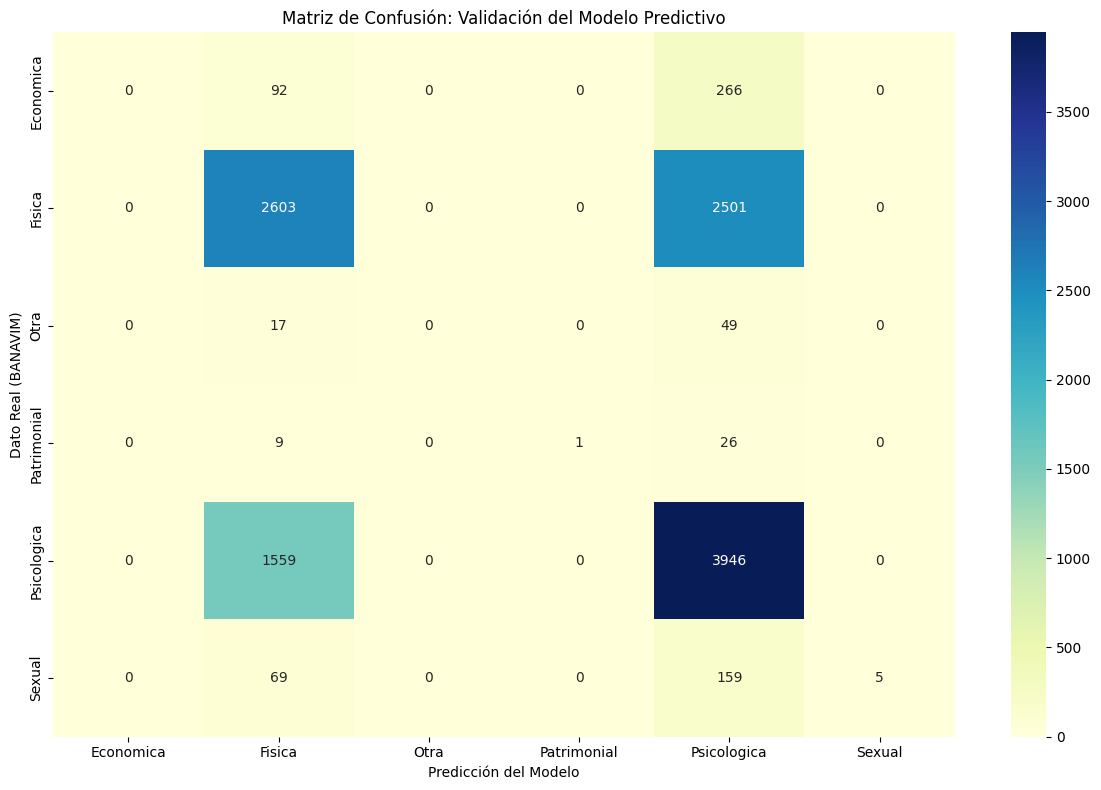

In [739]:
y_predichas = modelo.predict(X_numeric)
conf_matrix = confusion_matrix(y, y_predichas)

plt.figure(figsize=(12, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=modelo.classes_,
            yticklabels=modelo.classes_)
plt.title('Matriz de Confusión: Validación del Modelo Predictivo')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Dato Real (BANAVIM)')
plt.tight_layout()
plt.show()

In [740]:
print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y, y_predichas))


--- REPORTE DE CLASIFICACIÓN ---


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

   Economica       0.00      0.00      0.00       358
      Fisica       0.60      0.51      0.55      5104
        Otra       0.00      0.00      0.00        66
 Patrimonial       1.00      0.03      0.05        36
 Psicologica       0.57      0.72      0.63      5505
      Sexual       1.00      0.02      0.04       233

    accuracy                           0.58     11302
   macro avg       0.53      0.21      0.21     11302
weighted avg       0.57      0.58      0.56     11302



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [741]:
top_patrones = casos_analisis.groupby(variables_patron).size().reset_index(name='Casos')
top_patrones = top_patrones.sort_values(by='Casos', ascending=False).head(5)

In [742]:
final_results = []
for _, row in top_patrones.iterrows():
    # Convertir el patrón real a su código numérico
    input_encoded = [encoders[col].transform([row[col]])[0] for col in variables_patron]

    pred = modelo.predict([input_encoded])[0]
    prob = modelo.predict_proba([input_encoded]).max()

    final_results.append({
        'Lugar': row['lugarhechos'],
        'Sustancias': row['droga_agresion'],
        'Predicción': pred,
        'Confianza': f"{prob:.1%}"
    })

print(pd.DataFrame(final_results).to_markdown(index=False))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/usr/local

| Lugar              | Sustancias   | Predicción   | Confianza   |
|:-------------------|:-------------|:-------------|:------------|
| Espacio particular | No           | Psicologica  | 52.9%       |
| Espacio particular | Desconocido  | Fisica       | 55.4%       |
| Espacio particular | Si           | Fisica       | 64.9%       |
| Espacio particular | Desconocido  | Psicologica  | 44.3%       |
| Espacio particular | No           | Psicologica  | 53.7%       |


Matriz de Probabilidad de Riesgo

Zona Verde (Riesgo Base): Espacio particular + Sin sustancias = 52.9% Psicológica.

Zona Roja (Alerta Máxima): Espacio particular + Con sustancias = 64.9% Física.

# Insights: Victimas

In [841]:
victimas.columns = victimas.columns.str.lower()

In [842]:
victimas = victimas.applymap(lambda x: x.strip() if isinstance(x, str) else x)

/tmp/ipykernel_4679/1821097348.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  victimas = victimas.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [843]:
victimas["municipio"] = victimas["municipio"].apply(Limpiar)

In [844]:
victimas["edad"] = pd.to_numeric(victimas["edad"], errors="coerce")

In [845]:
victimas = victimas.dropna(subset=["municipio", "edad"])

In [846]:
bins = [0, 12, 17, 25, 35, 50, 100]
labels = ["Niñas", "Adolescentes", "Jóvenes", "Adultas jóvenes", "Adultas", "Mayores"]
victimas["grupo_edad"] = pd.cut(victimas["edad"], bins=bins, labels=labels)

In [847]:
edad_promedio = victimas["edad"].mean()
print(f"1. Edad Promedio de la Víctima: {edad_promedio:.1f} años")
grupo_dom = victimas["grupo_edad"].value_counts(normalize=True).head(1)
print(f"📊 La violencia se concentra mayoritariamente en la etapa reproductiva y productiva. El grupo dominante es '{grupo_dom.index[0]}' ({grupo_dom.values[0]*100:.1f}% de los casos).\n")

1. Edad Promedio de la Víctima: 35.6 años
📊 La violencia se concentra mayoritariamente en la etapa reproductiva y productiva. El grupo dominante es 'Adultas' (31.4% de los casos).





---



In [848]:
cols_perfil = ['grupo_edad']
if 'escolaridad' in victimas.columns: cols_perfil.append('escolaridad')
if 'estadocivil' in victimas.columns: cols_perfil.append('estadocivil')
if 'ocupacion' in victimas.columns: cols_perfil.append('ocupacion')
elif 'actividad' in victimas.columns: cols_perfil.append('actividad')

In [849]:
df_modelo = victimas[cols_perfil].copy()
for col in cols_perfil:
    df_modelo[col] = df_modelo[col].astype(str).replace(['nan', 'None', 'NaN', ''], 'No identificado')

In [850]:
encoders = {}
df_numeric = pd.DataFrame()
for col in cols_perfil:
    le = LabelEncoder()
    df_numeric[col] = le.fit_transform(df_modelo[col])
    encoders[col] = le

In [851]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

In [852]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
victimas['Cluster'] = kmeans.fit_predict(X_scaled)

In [853]:
pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)
victimas['PCA1'] = componentes[:, 0]
victimas['PCA2'] = componentes[:, 1]

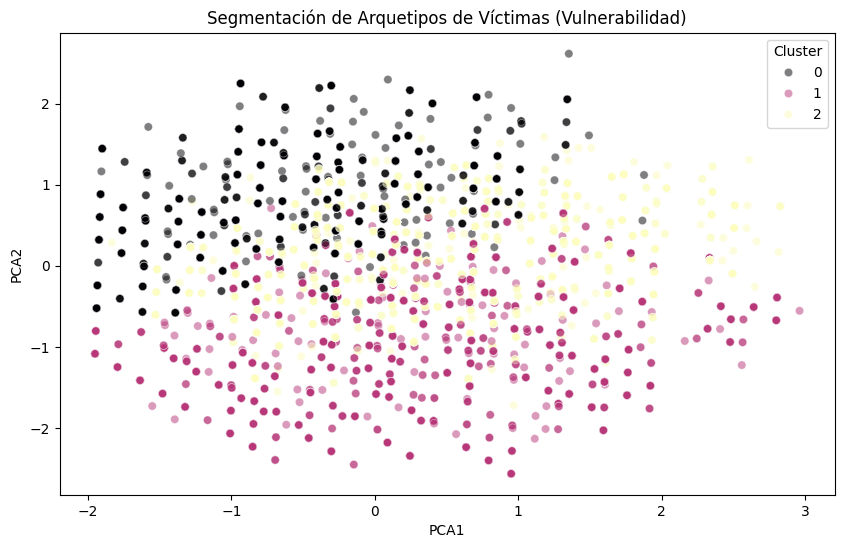

In [854]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='magma', data=victimas, alpha=0.5)
plt.title('Segmentación de Arquetipos de Víctimas (Vulnerabilidad)')
plt.savefig('cluster_victimas.png')
plt.show()

In [855]:
print("\n--- RESUMEN DE ARQUETIPOS DE VÍCTIMAS ---")
for i in range(3):
    c = victimas[victimas['Cluster'] == i]
    print(f"\nPERFIL {i} (N={len(c)} casos):")
    for col in cols_perfil:
        moda = df_modelo.loc[c.index][col].mode()[0]
        print(f" - {col.capitalize()}: {moda}")


--- RESUMEN DE ARQUETIPOS DE VÍCTIMAS ---

PERFIL 0 (N=3458 casos):
 - Grupo_edad: Adultas
 - Escolaridad: Secundaria
 - Estadocivil: Casada
 - Ocupacion: Hogar

PERFIL 1 (N=3503 casos):
 - Grupo_edad: Adultas jóvenes
 - Escolaridad: Licenciatura
 - Estadocivil: Soltera
 - Ocupacion: Trabaja

PERFIL 2 (N=4718 casos):
 - Grupo_edad: Adultas jóvenes
 - Escolaridad: Secundaria
 - Estadocivil: Soltera
 - Ocupacion: Hogar


Conclusión del modelo: 'la víctima' no es un ente homogéneo. Existen perfiles con necesidades de rescate muy distintas.

# Insights: Agresores

In [829]:
agresores['municipio'].unique().tolist()

['Zozocolco De Hidalgo',
 'Cerro Azul',
 'Veracruz',
 'Xalapa',
 'Ayahualulco',
 'Huatusco',
 'Uxpanapa',
 'Alamo Temapache',
 'Tuxpan',
 'Coatzacoalcos',
 'San Andres Tuxtla',
 'Cosamaloapan De Carpio',
 'Cordoba',
 'Las Choapas',
 'Orizaba',
 'Tequila',
 'Martinez De La Torre',
 'Misantla',
 'Alvarado',
 'Coscomatepec',
 'Tlapacoyan',
 'Perote',
 'Boca Del Rio',
 'Rio Blanco',
 'Mariano Escobedo',
 'Atzacan',
 'La Perla',
 'Ixtaczoquitlan',
 'Nogales',
 'Papantla',
 'Zongolica',
 'Minatitlan',
 'Angel R. Cabada',
 'Carrillo Puerto',
 'Poza Rica De Hidalgo',
 'Agua Dulce',
 'Ozuluama De Mascarenas',
 'Tezonapa',
 'Coatzintla',
 'Acajete',
 'Ixhuatlan De Madero',
 'Zacualpan',
 'El Higo',
 'Tres Valles',
 'Panuco',
 'Espinal',
 'Chiconamel',
 'Tamiahua',
 'Amatlan De Los Reyes',
 'San Juan Evangelista',
 'Tempoal',
 'Paso De Ovejas',
 'Hidalgotitlan',
 'Tierra Blanca',
 'Coahuitlan',
 'Cuitlahuac',
 'Fortin',
 'Cuichapa',
 'Yanga',
 'Chocaman',
 'Chalma',
 'Cosoleacaque',
 'Paso Del Ma

In [830]:
agresores["municipio"] = agresores["municipio"].apply(Limpiar)

In [831]:
agresores['municipio'].unique().tolist()

['Zozocolco De Hidalgo',
 'Cerro Azul',
 'Veracruz',
 'Xalapa',
 'Ayahualulco',
 'Huatusco',
 'Uxpanapa',
 'Alamo Temapache',
 'Tuxpan',
 'Coatzacoalcos',
 'San Andres Tuxtla',
 'Cosamaloapan De Carpio',
 'Cordoba',
 'Las Choapas',
 'Orizaba',
 'Tequila',
 'Martinez De La Torre',
 'Misantla',
 'Alvarado',
 'Coscomatepec',
 'Tlapacoyan',
 'Perote',
 'Boca Del Rio',
 'Rio Blanco',
 'Mariano Escobedo',
 'Atzacan',
 'La Perla',
 'Ixtaczoquitlan',
 'Nogales',
 'Papantla',
 'Zongolica',
 'Minatitlan',
 'Angel R. Cabada',
 'Carrillo Puerto',
 'Poza Rica De Hidalgo',
 'Agua Dulce',
 'Ozuluama De Mascarenas',
 'Tezonapa',
 'Coatzintla',
 'Acajete',
 'Ixhuatlan De Madero',
 'Zacualpan',
 'El Higo',
 'Tres Valles',
 'Panuco',
 'Espinal',
 'Chiconamel',
 'Tamiahua',
 'Amatlan De Los Reyes',
 'San Juan Evangelista',
 'Tempoal',
 'Paso De Ovejas',
 'Hidalgotitlan',
 'Tierra Blanca',
 'Coahuitlan',
 'Cuitlahuac',
 'Fortin',
 'Cuichapa',
 'Yanga',
 'Chocaman',
 'Chalma',
 'Cosoleacaque',
 'Paso Del Ma

In [832]:
top_vinculos = agresores['vinculo_victima'].value_counts(normalize=True).head(2) * 100
pareja_ex = top_vinculos.sum()
print(f"1. Vínculo principal con la víctima:\n{top_vinculos.round(1)}\n")

1. Vínculo principal con la víctima:
vinculo_victima
Pareja       38.8
Ex pareja    27.2
Name: proportion, dtype: float64



💍 El 66.0% de las agresiones provienen del círculo íntimo (Pareja y Ex pareja).



---



In [834]:
actividad = agresores['actividad'].value_counts(normalize=True).head(3) * 100
print(f"\n2. Estatus laboral del agresor:\n{actividad.round(1)}\n")


2. Estatus laboral del agresor:
actividad
Trabaja        67.3
Desconocido    15.7
Hogar           6.0
Name: proportion, dtype: float64



💼 El 67.3% de los agresores son hombres económicamente activos ('Trabaja').



---



In [836]:
escolaridad = agresores['escolaridad'].value_counts(normalize=True).head(5) * 100
licenciatura_pct = escolaridad.get('Licenciatura', 0)
print(f"\n3. Nivel de Escolaridad:\n{escolaridad.round(1)}\n")


3. Nivel de Escolaridad:
escolaridad
Secundaria         22.5
No identificado    21.8
Preparatoria       19.5
Primaria           16.3
Licenciatura       15.2
Name: proportion, dtype: float64



🎓 Un 15.2% de los agresores cuentan con grado de Licenciatura.



---



In [838]:
edad_grupos = agresores['grupo_edad'].value_counts(normalize=True).head(3) * 100
print(f"\n4. Grupos de Edad predominantes:\n{edad_grupos.round(1)}\n")


4. Grupos de Edad predominantes:
grupo_edad
Adulto          44.5
Joven           23.9
Adulto mayor    23.6
Name: proportion, dtype: float64



👤 La violencia se concentra en la etapa 'Adulta' (44.5%), la fase de mayor consolidación patrimonial y familiar.



---



In [776]:
columnas_perfil = ['estadocivil', 'escolaridad', 'vinculo_victima', 'grupo_edad', 'actividad']
df_modelo = agresores[columnas_perfil].copy()

In [777]:
for col in columnas_perfil:
    df_modelo[col] = df_modelo[col].astype(str).replace(['nan', 'None', 'NaN', ''], 'No identificado')

In [778]:
encoders = {}
df_numeric = pd.DataFrame()
for col in columnas_perfil:
    le = LabelEncoder()
    df_numeric[col] = le.fit_transform(df_modelo[col])
    encoders[col] = le

In [779]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_numeric)

In [780]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
agresores['Cluster'] = kmeans.fit_predict(X_scaled)

In [781]:
pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(X_scaled)
agresores['PCA1'] = componentes_pca[:, 0]
agresores['PCA2'] = componentes_pca[:, 1]

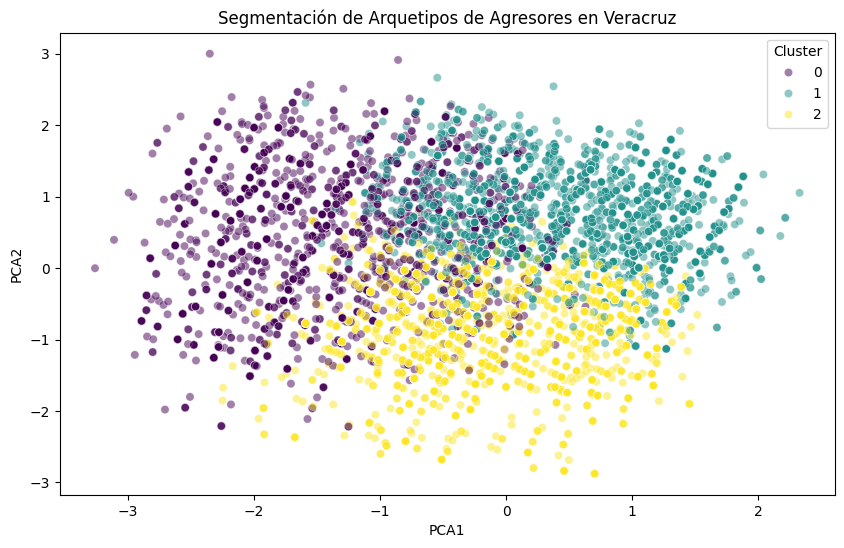

In [782]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', palette='viridis', data=agresores, alpha=0.5)
plt.title('Segmentación de Arquetipos de Agresores en Veracruz')
plt.savefig('cluster_results.png')
plt.show()

In [783]:
print("--- RESUMEN DE ARQUETIPOS ENCONTRADOS ---")
for i in range(3):
    c = agresores[agresores['Cluster'] == i]
    print(f"\nGRUPO {i} (N={len(c)}):")
    for col in columnas_perfil:
        moda = df_modelo.loc[c.index][col].mode()[0]
        print(f" - {col}: {moda}")

--- RESUMEN DE ARQUETIPOS ENCONTRADOS ---

GRUPO 0 (N=2293):
 - estadocivil: No identificado
 - escolaridad: No identificado
 - vinculo_victima: Pareja
 - grupo_edad: Adulto
 - actividad: Desconocido

GRUPO 1 (N=4339):
 - estadocivil: Unión libre
 - escolaridad: Secundaria
 - vinculo_victima: Ex pareja
 - grupo_edad: Adulto
 - actividad: Trabaja

GRUPO 2 (N=3478):
 - estadocivil: Casado
 - escolaridad: Secundaria
 - vinculo_victima: Pareja
 - grupo_edad: Adulto
 - actividad: Trabaja


# SECCION ANALISIS 1

Prueba

In [ ]:
agresoresmayor = agresores[agresores['edad'] >= 18]

In [ ]:
bins = [18,29,44,59,100]
labels = ['18-29','30-44','45-59','60+']

agresores['grupo_edad'] = pd.cut(agresores['edad'], bins=bins, labels=labels)

In [ ]:
agresores['vinculo_limpio'] = agresores['vinculo_victima'].apply(agrupar_vinculo)

In [ ]:
def agrupar_vinculo(x):
    if pd.isna(x):
        return 'No especificado'

    x = str(x)

    if any(p in x for p in ['Esposo', 'Pareja', 'Concubino', 'Novio']):
        return 'Pareja'

    elif any(p in x for p in ['Padre', 'Madre', 'Hermano', 'Primo', 'Sobrino', 'Tio', 'Hijo']):
        return 'Familiar'

    elif 'Desconocido' in x:
        return 'Desconocido'

    elif any(p in x for p in ['Servidor público', 'Policía', 'Autoridad']):
        return 'Autoridad'

    else:
        return 'Otro vínculo'

In [ ]:
cruce = agresoresmayor.groupby(
    ['grupo_edad','vinculo_limpio'],
    observed=True
).size().reset_index(name='casos')

cruce['total'] = cruce.groupby(
    'grupo_edad',
    observed=True
)['casos'].transform('sum')

cruce['porcentaje'] = cruce['casos'] / cruce['total']

In [ ]:
print(cruce.head())

  grupo_edad vinculo_limpio  casos  total  porcentaje
0      18-29    Desconocido     95   2003    0.047429
1      18-29       Familiar     91   2003    0.045432
2      18-29          Otros   1126   2003    0.562157
3      18-29         Pareja    691   2003    0.344983
4      30-44      Autoridad     18   4630    0.003888
